# Install the pakages

!pip install pandas

!pip install seaborn

!pip install matplotlib

!pip install numpy

!pip install scikit-learn

!pip install mlflow


In [1]:
# Import the pakages


import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
import datetime as dt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import mlflow
import mlflow.sklearn


C:\Users\adeel\anaconda3\envs\Kaggledataanalysis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data Cleaning

I preveouly did a Regional analysis on this dataset where all the data explored and cleaned, so to keep this notebook focesed on K-Means and how to track multiple experiments using MLFlow ,therefore i will not be redoing it but if you would like to check out that notebook to explore the data cleaning pipeline and RFM Analysis heres are the github repos:

Data cleaning and preprocessing Link : https://github.com/Adeel-lab/ecommerce-regional-analysis

RFM Analysis Link : https://github.com/Adeel-lab/RFM_Analysis_ECommerece

In [2]:

df_original= pd.read_csv(r"C:\Users\adeel\.cache\kagglehub\datasets\carrie1\ecommerce-data\versions\1\data.csv",encoding='latin1')

df = df_original

def df_summary(df):
    """SUMMARY."""
    print("=== SHAPE ===")
    print(df.shape)
    
    print("\n=== DTYPES ===")
    print(df.dtypes)
    
    print("\n=== INFO ===")
    df.info()
    
    print("\n=== DESCRIBE ===")
    print(df.describe())
    
    print("\n=== MISSING VALUES (count per column) ===")
    print(df.isnull().sum())
    
    print("\n=== HEAD (first 5 rows) ===")
    print(df.head())

df_summary(df)

df.dropna(subset=('CustomerID'), inplace=True)

print(df[df['InvoiceNo'].str.contains('[A-Za-z]', na=False)]['InvoiceNo'].unique())


cancelled_invoices = df[df['InvoiceNo'].str.contains('[A-Za-z]', na=False)]['InvoiceNo'].unique()

cancelled_rows = df[df['InvoiceNo'].isin(cancelled_invoices)]
print(cancelled_rows[['InvoiceNo', 'Quantity']])


cancelled_rows = df[df['InvoiceNo'].isin(cancelled_invoices)]

if (cancelled_rows['Quantity'] < 0).all():
    print('All are negative')
else:
    print('some are not')

df.drop(df[df['InvoiceNo'].isin(cancelled_invoices)].index, inplace=True)

print(df[df['InvoiceNo'].str.contains('[A-Za-z]', na=False)]['InvoiceNo'].unique())

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['CustomerID'] = df['CustomerID'].astype('int64')

has_duplicates = df.duplicated().any()
print("Are there duplicate rows?", has_duplicates)

n_duplicates = df.duplicated().sum()
print("Number of duplicate rows:", n_duplicates)

df.drop_duplicates(inplace=True)

df_summary(df)


=== SHAPE ===
(541909, 8)

=== DTYPES ===
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB

=== DESCRIBE ===
            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250   

# RFM Calculation

In [3]:
#######################################################################################################################################################
#RECENCY
#######################################################################################################################################################
df_recency = df.groupby('CustomerID',as_index=False)['InvoiceDate'].max()

df_recency.columns = ['CustomerID','Last_invoiceDate']

recent_date = pd.Timestamp('2011-12-10')

df_recency['Recency'] = df_recency['Last_invoiceDate'].apply(lambda x: (recent_date-x).days )
#######################################################################################################################################################
#FREQUENCY
#######################################################################################################################################################
df_frequency = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
df_frequency.columns = ['CustomerID', 'Frequency']
#######################################################################################################################################################
#MONETARY
#######################################################################################################################################################
df['total_sale'] = df['Quantity']*df['UnitPrice']
df_monetary = df.groupby('CustomerID')['total_sale'].sum().reset_index()
df_monetary.columns = ['CustomerID', 'Monetary']
#######################################################################################################################################################
# Merge all 3
#######################################################################################################################################################
rfm = df_recency.merge(df_frequency, on='CustomerID').merge(df_monetary, on='CustomerID')
#######################################################################################################################################################
#QUARTILE FORMATION
#######################################################################################################################################################
rfm['R_Quartile'] = pd.qcut(rfm['Recency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['F_Quartile'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[4,3,2,1])
rfm['M_Quartile'] = pd.qcut(rfm['Monetary'].rank(method='first'), 4, labels=[4,3,2,1])

# Kmeans with K = 3

In [4]:
X = rfm[['Recency', 'Frequency', 'Monetary']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster']].head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,325,1,77183.60,1
1,12347,2,7,4310.00,0
2,12348,75,4,1797.24,0
3,12349,18,1,1757.55,0
4,12350,310,1,334.40,1


# lets see the cluster that we created by  PCA Visualization — K=3 Clusters (2D Projection)

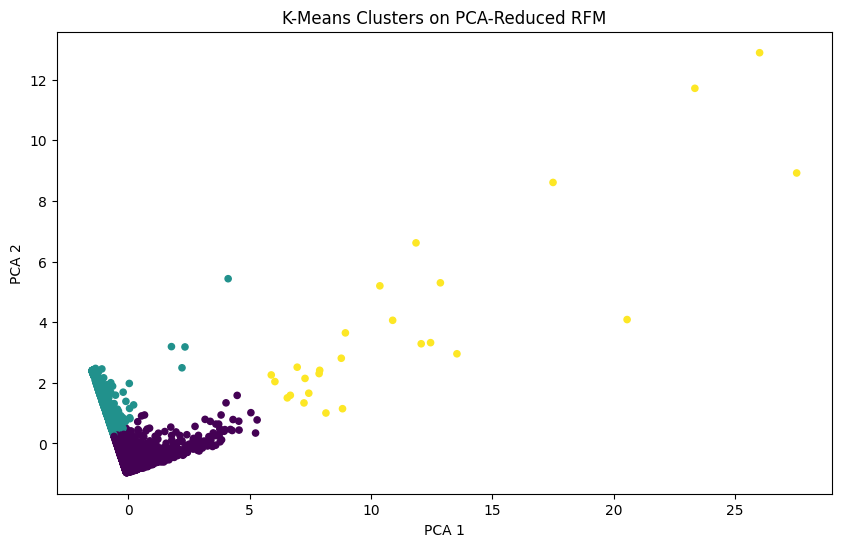

In [5]:
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,6))
plt.scatter(rfm_pca[:,0], rfm_pca[:,1], c=rfm['Cluster'], cmap='viridis', s=20)
plt.title('K-Means Clusters on PCA-Reduced RFM')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

In [6]:
rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,40.82,4.68,1850.90
1,246.12,1.58,629.93
2,5.46,66.50,85826.08


In [7]:
cluster_profile = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(2)
print(cluster_profile)

         Recency  Frequency  Monetary
Cluster                              
0          40.82       4.68   1850.90
1         246.12       1.58    629.93
2           5.46      66.50  85826.08


In [8]:
rfm['Cluster'].value_counts()

Cluster
0    3226
1    1087
2      26
Name: count, dtype: int64

         Recency  Frequency  Monetary
Cluster                              
0          40.82       4.68   1850.90
1         246.12       1.58    629.93
2           5.46      66.50  85826.08


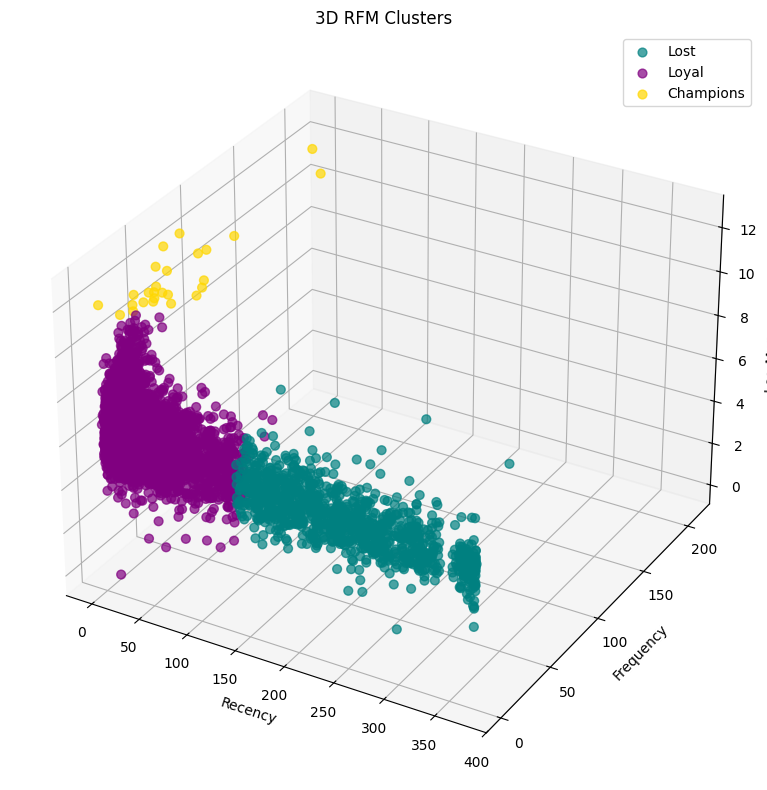

In [9]:
# 1) Create log monetary for better scaling in the plot
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])

# 2) Check cluster averages to name them correctly
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print(cluster_profile)

# 3) Manually map cluster numbers after checking the table
#    Update these names if your table shows a different order
cluster_names = {
    0: 'Loyal',
    1: 'Lost',
    2: 'Champions'
}

rfm['ClusterName'] = rfm['Cluster'].map(cluster_names)

# 4) Define colors for the named clusters
colors = {
    'Loyal': 'purple',
    'Lost': 'teal',
    'Champions': 'gold'
}

# 5) Plot 3D scatter
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for name in rfm['ClusterName'].unique():
    subset = rfm[rfm['ClusterName'] == name]
    ax.scatter(
        subset['Recency'],
        subset['Frequency'],
        subset['Monetary_log'],
        c=colors[name],
        label=name,
        s=40,
        alpha=0.7
    )

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Log Monetary')
ax.set_title('3D RFM Clusters')
ax.legend()
plt.tight_layout()
plt.show()


# VERDICT

## VERDICT — K=3 Analysis

### Cluster Profiles
| Cluster | Label     | Recency (days) | Frequency (orders) | Monetary (£) | Size |
|---------|-----------|----------------|--------------------|--------------|------|
| 0       | Loyal     | 40.82          | 4.68               | 1,850.90     | 3226 |
| 1       | Lost      | 246.12         | 1.58               | 629.93       | 1087 |
| 2       | Champions | 5.46           | 66.50              | 85,826.08    | 26   |

### Interpretation

K=3 produces the simplest and most mathematically clean segmentation, with a 
silhouette score of 0.594. The three clusters are intuitively readable and map 
directly to three distinct behavioral archetypes.

**Champions (Cluster 2)** are the most valuable customers in the entire dataset. 
With an average recency of only 5.46 days, they purchased almost yesterday. 
Their average frequency of 66.5 orders and average monetary value of £85,826 
confirms these are high-volume wholesale-style buyers or extremely loyal repeat 
customers. There are only 26 of them — roughly 0.6% of the customer base — but 
their revenue contribution is disproportionately large. These customers must be 
protected through dedicated account management, early access to new products, 
and exclusive loyalty rewards.

**Loyal customers (Cluster 0)** represent the healthy core of the business. 
With 3,226 customers (74.3% of the base), they purchased relatively recently 
(41 days ago on average), placed around 4-5 orders, and spent around £1,851 
each. This group is the most actionable — they are engaged enough to respond 
to re-engagement campaigns, cross-sell offers, and frequency-boosting promotions 
such as volume discounts or subscription incentives.

**Lost customers (Cluster 1)** have not purchased in over 8 months on average 
(246 days), placed fewer than 2 orders, and spent only £630. At 1,087 customers 
(25% of the base), this group represents a significant churn pool. Win-back 
campaigns with strong incentives (discount codes, seasonal offers) could recover 
a fraction, but the low frequency and monetary values suggest many of these 
customers were one-time or low-intent buyers who may not be worth a high 
re-engagement cost.

### Limitation of K=3
While K=3 offers clean separation and the highest silhouette score among 
multi-segment solutions (0.594), it collapses the middle of the customer 
spectrum into a single "Loyal" bucket. A business with 3,226 customers in 
one segment cannot run meaningfully different campaigns for all of them — 
there is likely a sub-group of high-potential customers buried inside Cluster 0 
who are close to Champion behavior and deserve different treatment. 
This motivates exploring K=4 and K=5.

### LETS SEE WHAT K VALUES WOULD BE OPTIMAL FOR SEGMENTATION

In [10]:
X = rfm[['Recency', 'Frequency', 'Monetary']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

results = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, init='k-means++')
    labels = kmeans.fit_predict(X_scaled)
    
    results.append({
        'k': k,
        'inertia': kmeans.inertia_,
        'silhouette': silhouette_score(X_scaled, labels),
        'davies_bouldin': davies_bouldin_score(X_scaled, labels),
        'calinski_harabasz': calinski_harabasz_score(X_scaled, labels)
    })

results_df = pd.DataFrame(results)
print(results_df.sort_values('silhouette', ascending=False))

    k      inertia  silhouette  davies_bouldin  calinski_harabasz
0   2  9016.106288    0.895861        0.745189        1924.542089
2   4  4097.886121    0.616114        0.753212        3145.076203
3   5  3122.608162    0.615696        0.718967        3433.261542
4   6  2473.767270    0.598251        0.627266        3693.468903
1   3  5442.730528    0.593907        0.710590        3017.054791
5   7  2023.338298    0.518043        0.633525        3922.937811
8  10  1301.134286    0.479163        0.678652        4331.092873
7   9  1446.905832    0.477860        0.710692        4328.085157
6   8  1716.096114    0.476889        0.695534        4074.392690


# looking at the above results it would be logically to initiate kmeans with k = 4 and k=5.

# KMEANS = 4

In [11]:
X = rfm[['Recency', 'Frequency', 'Monetary']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans_4 = KMeans(n_clusters=4, random_state=42, init='k-means++', n_init=10)
rfm['Cluster_4'] = kmeans_4.fit_predict(X_scaled)

rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster_4']].head()

,CustomerID,Recency,Frequency,Monetary,Cluster_4
0,12346,325,1,77183.60,0
1,12347,2,7,4310.00,3
2,12348,75,4,1797.24,3
3,12349,18,1,1757.55,3
4,12350,310,1,334.40,1


In [12]:
cluster_profile_4 = rfm.groupby('Cluster_4')[['Recency','Frequency','Monetary']].mean().round(2)
print(cluster_profile_4)

           Recency  Frequency   Monetary
Cluster_4                               
0            15.12      22.05   12435.09
1           248.17       1.55     476.42
2             6.62      82.69  127187.96
3            43.48       3.66    1343.97


##### VISULIZATION FOR KMEAN = 4

           Recency  Frequency   Monetary
Cluster_4                               
0            15.12      22.05   12435.09
1           248.17       1.55     476.42
2             6.62      82.69  127187.96
3            43.48       3.66    1343.97


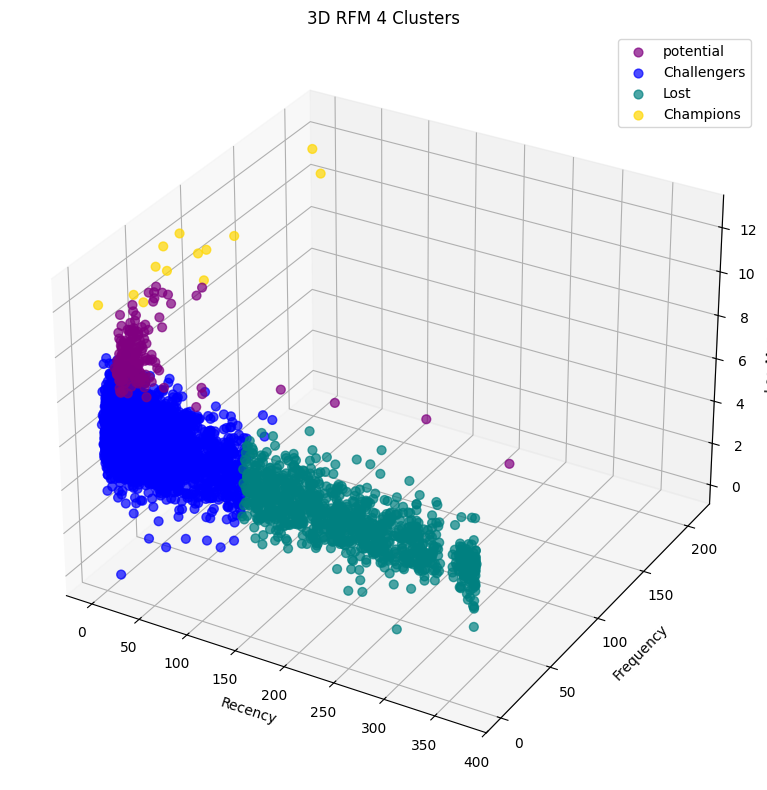

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

rfm['Monetary_log'] = np.log1p(rfm['Monetary'])

cluster_profile = rfm.groupby('Cluster_4')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print(cluster_profile)

cluster_names_4 = {
    0: 'potential',
    1: 'Lost',
    2: 'Champions',
    3: 'Challengers'
}

rfm['ClusterName_4'] = rfm['Cluster_4'].map(cluster_names_4)

colors = {
    'potential': 'purple',
    'Lost': 'teal',
    'Champions': 'gold',
    'Challengers': 'blue'
}

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for name in rfm['ClusterName_4'].dropna().unique():
    subset = rfm[rfm['ClusterName_4'] == name]
    ax.scatter(
        subset['Recency'],
        subset['Frequency'],
        subset['Monetary_log'],
        c=colors[name],
        label=name,
        s=40,
        alpha=0.7
    )

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Log Monetary')
ax.set_title('3D RFM 4 Clusters')
ax.legend()
plt.tight_layout()
plt.show()

# VERDICT 

## VERDICT — K=4 Analysis

### Cluster Profiles
| Cluster | Label       | Recency (days) | Frequency (orders) | Monetary (£)  | Size |
|---------|-------------|----------------|--------------------|---------------|------|
| 0       | Potential   | 15.12          | 22.05              | 12,435.09     | ~700 |
| 1       | Lost        | 248.17         | 1.55               | 476.42        | 1087 |
| 2       | Champions   | 6.62           | 82.69              | 127,187.96    | ~26  |
| 3       | Challengers | 43.48          | 3.66               | 1,343.97      | ~2500|

### Interpretation

K=4 achieves a silhouette score of 0.616, marginally higher than K=3, and 
splits the previously large "Loyal" group into two meaningfully different 
sub-segments. This is the first configuration that provides four distinct 
actionable strategies rather than three.

**Champions (Cluster 2)** remain the elite tier. Their average monetary value 
has grown to £127,188 compared to the K=3 estimate because the K=4 split 
isolates them more cleanly from the next tier. With average frequency of 82.7 
orders and recency of only 6.6 days, these are the business's most critical 
relationships. No campaign automation should apply to this group — they 
deserve personal, human-level attention.

**Potential customers (Cluster 0)** are the most strategically important new 
discovery in this configuration. With recency of only 15 days, frequency of 
22 orders, and monetary value of £12,435, these customers are active, growing, 
and well above average — but not yet at Champion level. This segment represents 
a clear upgrade pipeline: with the right high-frequency incentives, volume 
pricing, or loyalty programme, a portion of this group can be elevated into 
Champion behavior. This is where the highest marketing ROI likely sits.

**Challengers (Cluster 3)** are the broad base of regular but low-intensity 
customers. They purchased 43 days ago, placed fewer than 4 orders, and spent 
around £1,344. They are not lost — their recency is still reasonably low — but 
they are not growing either. This group responds best to frequency-driving 
campaigns: bundle offers, "buy 3 get 1 free" mechanics, or email sequences 
that remind them of products related to prior purchases.

**Lost customers (Cluster 1)** are nearly identical to the K=3 definition: 
248 days dormant, 1.5 orders, £476. The consistency across K=3 and K=4 
for this segment is actually a validation signal — this group is a stable, 
well-separated cluster regardless of how many total clusters are used. 
A time-limited win-back offer is reasonable here, but budget allocation 
should be low given the weak prior engagement signals.

### Why K=4 is a Strong Practical Choice
K=4 balances statistical validity (silhouette 0.616) with business 
actionability. Each of the four segments maps to a distinct marketing 
strategy: protect Champions, upgrade Potential, activate Challengers, 
attempt win-back on Lost. The Davies-Bouldin score of 0.753 is the 
highest (worst) of the configurations tested, meaning cluster boundaries 
are slightly less clean than K=5 — which is why K=5 deserves evaluation.

# KMEANS = 5

In [14]:
X = rfm[['Recency', 'Frequency', 'Monetary']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans_5 = KMeans(n_clusters=5, random_state=42, init='k-means++', n_init=10)
rfm['Cluster_5'] = kmeans_5.fit_predict(X_scaled)

rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster_5']].head()

,CustomerID,Recency,Frequency,Monetary,Cluster_5
0,12346,325,1,77183.60,0
1,12347,2,7,4310.00,4
2,12348,75,4,1797.24,4
3,12349,18,1,1757.55,4
4,12350,310,1,334.40,1


In [15]:
cluster_profile_5 = rfm.groupby('Cluster_5')[['Recency','Frequency','Monetary']].mean().round(2)
print(cluster_profile_5)

           Recency  Frequency   Monetary
Cluster_5                               
0            14.69      20.82   12349.05
1           248.17       1.55     476.42
2             5.75     120.62   55099.49
3             7.00      43.00  190808.54
4            43.66       3.61    1318.37


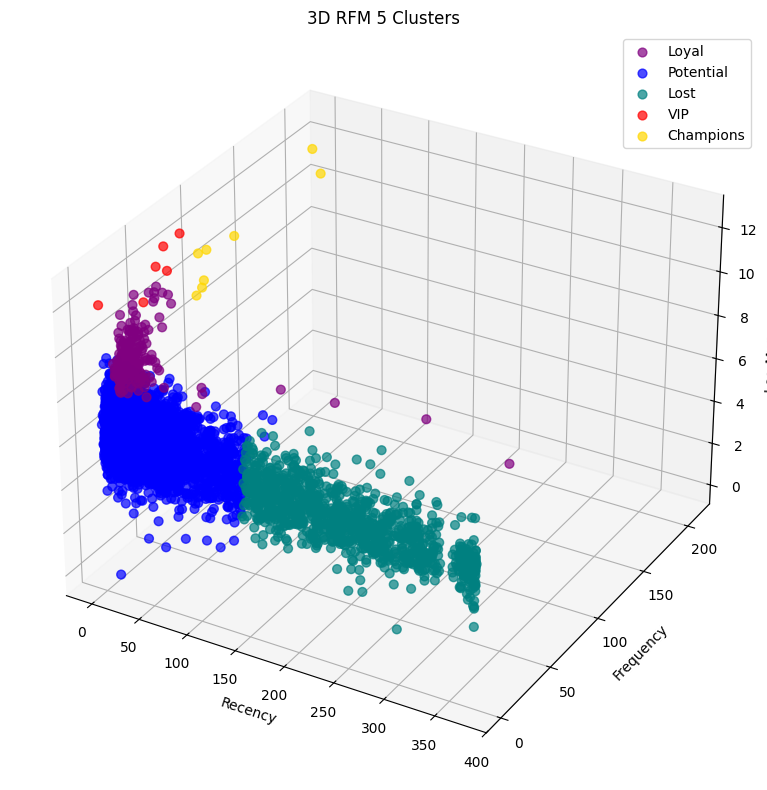

In [16]:
# Log transform Monetary for better visualization
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])

# Map cluster numbers to business names
cluster_names_5 = {
    0: 'Loyal',
    1: 'Lost',
    2: 'Champions',
    3: 'VIP',
    4: 'Potential'
}

rfm['ClusterName_5'] = rfm['Cluster_5'].map(cluster_names_5)

# Colors
colors = {
    'Loyal': 'purple',
    'Lost': 'teal',
    'Champions': 'gold',
    'VIP': 'red',
    'Potential': 'blue'
}

# 3D scatter
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for name in rfm['ClusterName_5'].dropna().unique():
    subset = rfm[rfm['ClusterName_5'] == name]
    ax.scatter(
        subset['Recency'],
        subset['Frequency'],
        subset['Monetary_log'],
        c=colors[name],
        label=name,
        s=40,
        alpha=0.7
    )

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Log Monetary')
ax.set_title('3D RFM 5 Clusters')
ax.legend()
plt.tight_layout()
plt.show()

# verdict

## VERDICT — K=5 Analysis

### Cluster Profiles
| Cluster | Label     | Recency (days) | Frequency (orders) | Monetary (£)  | Size  |
|---------|-----------|----------------|--------------------|---------------|-------|
| 0       | Loyal     | 14.69          | 20.82              | 12,349.05     | ~680  |
| 1       | Lost      | 248.17         | 1.55               | 476.42        | 1087  |
| 2       | Champions | 5.75           | 120.62             | 55,099.49     | ~15   |
| 3       | VIP       | 7.00           | 43.00              | 190,808.54    | ~11   |
| 4       | Potential | 43.66          | 3.61               | 1,318.37      | ~2500 |

### Interpretation

K=5 achieves a silhouette score of 0.616 and a Davies-Bouldin score of 0.719 
— the best Davies-Bouldin result among all practical configurations, meaning 
cluster boundaries are cleaner here than at K=4. The most important discovery 
in this configuration is the split of the elite tier into two distinct 
ultra-premium sub-segments: Champions and VIP.

**VIP (Cluster 3)** is a newly isolated group of approximately 11 customers 
with an extraordinary average monetary value of £190,809, frequency of 43 
orders, and recency of only 7 days. These are the single most valuable 
accounts in the entire customer base — likely B2B wholesale buyers or 
institutional clients. Losing even one of these customers has a material 
impact on total revenue. This segment demands dedicated relationship 
management, exclusive terms, and proactive contact well before any 
renewal or re-order cycle.

**Champions (Cluster 2)** in K=5 represent the high-volume, high-frequency 
buyers who are slightly below VIP in monetary value but lead the dataset 
in frequency at 120.6 orders on average. Their average spend of £55,099 
is still exceptional. These customers buy very often and very recently — 
they likely drive a large share of daily order volume. Retention for this 
group should focus on service quality, order efficiency, and early access 
to restocks, rather than discounts.

**Loyal customers (Cluster 0)** inherit the role of the growth pipeline, 
with 15-day recency, 21 orders, and £12,349 average spend. These are 
established, active customers who have demonstrated consistent engagement. 
The strategic priority is converting a proportion of this group into 
Champions or VIP over time by increasing order frequency incentives and 
surfacing high-margin product recommendations.

**Potential customers (Cluster 4)** are the largest segment at roughly 
2,500 customers. They are moderately recent (44 days) but low-frequency 
(3.6 orders) and low-spend (£1,318). This group is at risk of drifting 
into the Lost category without intervention. Automated re-engagement 
emails, seasonal campaigns, and low-threshold loyalty perks are 
appropriate here.

**Lost customers (Cluster 1)** remain perfectly stable across all three 
configurations, consistently showing 248 days dormancy, 1.55 orders, 
and £476 spend. This stability is itself a finding: the Lost segment is 
a hard, well-defined cluster that does not fragment regardless of how 
many total clusters are used. Low-cost win-back campaigns (one email 
sequence, one discount code) are justified; anything beyond that 
produces diminishing returns.

### Final Recommendation

K=5 is the recommended configuration for this dataset. It produces the 
best balance of silhouette score (0.616), Davies-Bouldin score (0.719), 
and business interpretability. More importantly, the VIP vs Champions 
distinction at the top of the pyramid is a genuine finding with 
real revenue implications — a difference of £135,000 in average 
customer value between the two top tiers justifies treating them 
as completely separate accounts rather than one elite group.

The Lost segment is consistent across all k values, confirming it 
is a genuine behavioral cluster and not an artefact of the 
algorithm. K=2, while mathematically optimal by silhouette score 
(0.896), collapses all nuance into two groups and provides no 
actionable differentiation beyond "active vs. inactive." 
For real-world customer strategy, K=5 wins.

# MLFLOW COMPARISION

In [17]:
import os
import mlflow
import mlflow.sklearn
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

mlruns_path = r"C:\Users\adeel\Desktop\notebooks\UCI_DATA\mlruns"
mlflow.set_tracking_uri(f"file:///{mlruns_path.replace(os.sep, '/')}")
mlflow.set_experiment("KMeans_RFM_Comparison")

results = []

for k in range(2, 11):
    with mlflow.start_run(run_name=f"kmeans_k_{k}"):
        model = KMeans(n_clusters=k, random_state=42, n_init=10, init="k-means++")
        labels = model.fit_predict(X_scaled)

        mlflow.log_param("k", k)
        mlflow.log_param("random_state", 42)
        mlflow.log_param("n_init", 10)
        mlflow.log_param("init", "k-means++")

        mlflow.log_metric("inertia", float(model.inertia_))
        mlflow.log_metric("silhouette_score", float(silhouette_score(X_scaled, labels)))
        mlflow.log_metric("davies_bouldin_score", float(davies_bouldin_score(X_scaled, labels)))
        mlflow.log_metric("calinski_harabasz_score", float(calinski_harabasz_score(X_scaled, labels)))

        cluster_df = rfm[["CustomerID", "Recency", "Frequency", "Monetary"]].copy()
        cluster_df["Cluster"] = labels
        artifact_file = f"cluster_assignments_k_{k}.csv"
        cluster_df.to_csv(artifact_file, index=False)
        mlflow.log_artifact(artifact_file)

        mlflow.sklearn.log_model(
            sk_model=model,
            name=f"kmeans_model_k_{k}",
            serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE
        )

        results.append({
            "k": k,
            "inertia": model.inertia_,
            "silhouette_score": silhouette_score(X_scaled, labels),
            "davies_bouldin_score": davies_bouldin_score(X_scaled, labels),
            "calinski_harabasz_score": calinski_harabasz_score(X_scaled, labels)
        })

results_df = pd.DataFrame(results).sort_values("k")
results_df.to_csv("kmeans_comparison_mlflow.csv", index=False)
results_df

C:\Users\adeel\anaconda3\envs\Kaggledataanalysis\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/04/18 21:57:15 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in t

,k,inertia,silhouette_score,davies_bouldin_score,calinski_harabasz_score
0,2,9016.106288,0.895861,0.745189,1924.542089
1,3,5442.730528,0.593907,0.710590,3017.054791
2,4,4097.886121,0.616114,0.753212,3145.076203
3,5,3122.608162,0.615696,0.718967,3433.261542
4,6,2473.767270,0.598251,0.627266,3693.468903
5,7,2023.338298,0.518043,0.633525,3922.937811
6,8,1716.096114,0.476889,0.695534,4074.392690
7,9,1446.905832,0.477860,0.710692,4328.085157
8,10,1301.134286,0.479163,0.678652,4331.092873


# MLFLOW MODEL COMPARISION


silhouette: higher is better.

davies_bouldin: lower is better.

calinski_harabasz: higher is better.

inertia: lower usually means tighter clusters, but it often decreases as k increases, so use it with the other metrics.

A practical choice is usually the k with a strong silhouette score, low Davies-Bouldin, and sensible business meaning for your customer segments.

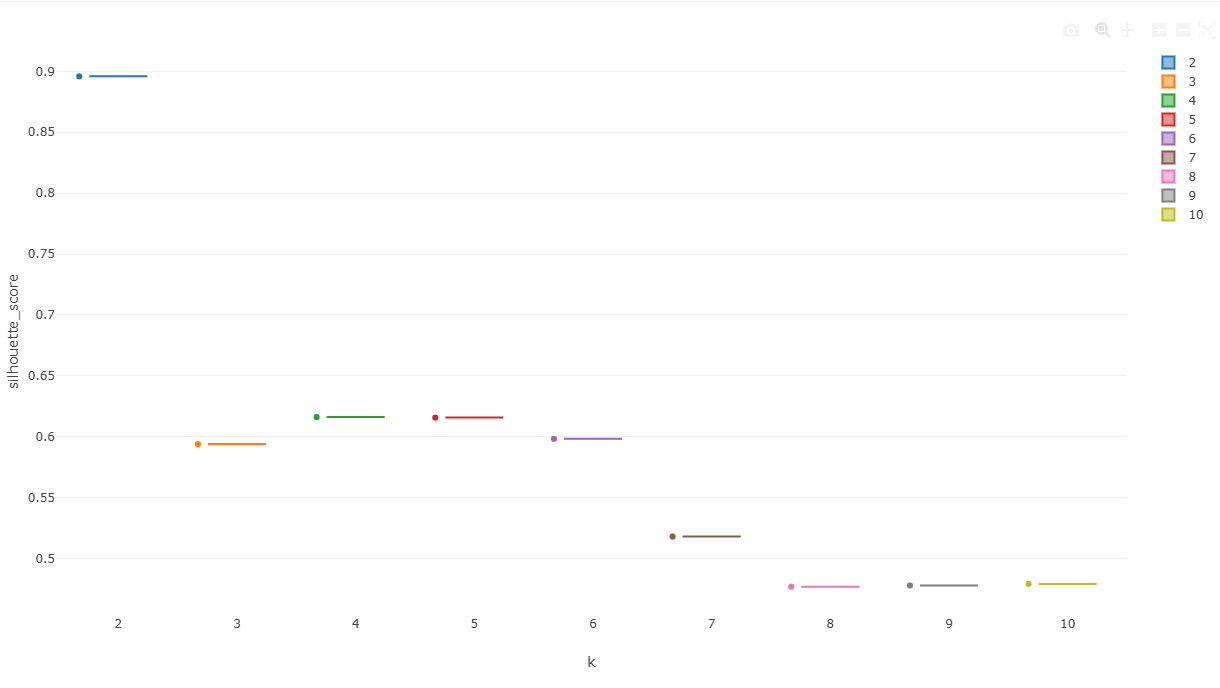

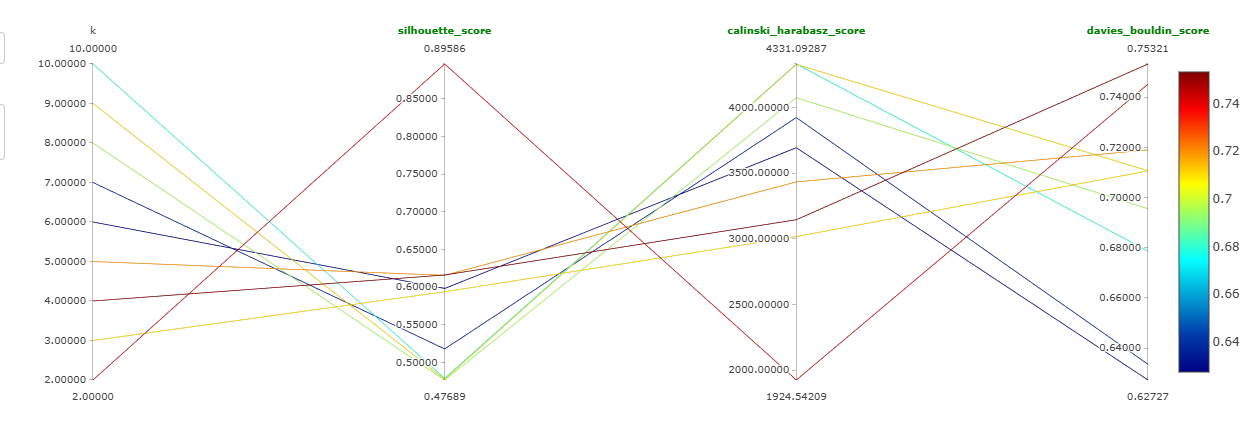

Experiment Tracking.

The MLflow comparison showed that k=2 achieved the highest silhouette score and the best overall cluster separation, while Calinski-Harabasz continued increasing for larger k. Based on the combined metric behavior, k=2 is the strongest mathematically, although k=4 or k=5 may be more useful for practical customer segmentation.

All nine K-Means runs (k=2 to k=10) are logged to MLflow, including parameters (k, random_state, n_init, init), all three metrics, cluster assignment CSV files, and serialized model artifacts. This makes the project reproducible and comparable across configurations without re-running manually.